#Property Price Estimator
**Business question:** Given a house's size, rooms, age, location and distance from the city, what should its asking price be, and which factors move the price most?

Run cells top to bottom (Runtime → Run all). When the upload box appears, choose `house_price_data.csv`.

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# Dataset is here
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

Saving house_price_data.csv to house_price_data.csv


In [ ]:
df = pd.read_csv(fname)
df.columns = df.columns.str.strip()
df["Location"] = df["Location"].astype(str).str.strip()

# If Garage is stored as text (Yes/No), turn it into 1/0
if df["Garage"].dtype == object:
    df["Garage"] = df["Garage"].str.strip().str.lower().map(
        {"yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0})

print("Shape:", df.shape)
df.head()

Shape: (600, 10)


,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Price_Lakh
0,3001,Chittagong,1422,3,4,20,1,"1,783.00",33.90,122.90
1,3002,Dhaka,3796,5,3,13,1,"1,410.80",13.20,499.80
2,3003,Sylhet,1010,5,1,9,1,0.00,7.80,99.60
3,3004,Rajshahi,2413,4,1,3,0,NaN,31.00,119.10
4,3005,Sylhet,2256,2,2,9,1,0.00,16.90,137.50


## 1. Data dictionary

In [ ]:
meaning = {
    "HouseID": "Unique identifier of the listing (NOT a feature)",
    "Location": "City where the house is (Dhaka, Chattogram, Sylhet, Rajshahi)",
    "Area_sqft": "Built-up floor area",
    "Bedrooms": "Number of bedrooms",
    "Bathrooms": "Number of bathrooms",
    "HouseAge_years": "Age of the house",
    "Garage": "Has a garage (1) or not (0) / number of garages",
    "GardenArea_sqft": "Garden size; 0 = no garden",
    "DistanceToCity_km": "Distance from the city centre",
    "Price_Lakh": "Asking price (TARGET)",
}
units = {"Area_sqft": "sq ft", "GardenArea_sqft": "sq ft", "HouseAge_years": "years",
         "DistanceToCity_km": "km", "Price_Lakh": "lakh BDT", "Bedrooms": "count",
         "Bathrooms": "count", "Garage": "0/1 or count", "Location": "category", "HouseID": "id"}

data_dict = pd.DataFrame({
    "Column": df.columns,
    "Meaning": df.columns.map(meaning),
    "Unit": df.columns.map(units),
    "Type": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values,
    "Unique values": df.nunique().values,
})
data_dict

,Column,Meaning,Unit,Type,Missing,Unique values
0,HouseID,Unique identifier of the listing (NOT a feature),id,int64,0,600
1,Location,"City where the house is (Dhaka, Chattogram, Sy...",category,object,0,4
2,Area_sqft,Built-up floor area,sq ft,int64,0,549
3,Bedrooms,Number of bedrooms,count,int64,0,7
4,Bathrooms,Number of bathrooms,count,int64,0,5
5,HouseAge_years,Age of the house,years,int64,0,41
6,Garage,Has a garage (1) or not (0) / number of garages,0/1 or count,int64,0,2
7,GardenArea_sqft,Garden size; 0 = no garden,sq ft,float64,30,339
8,DistanceToCity_km,Distance from the city centre,km,float64,24,285
9,Price_Lakh,Asking price (TARGET),lakh BDT,float64,0,544


## 2. Data audit

In [ ]:
print("Missing values per column:\n", df.isna().sum(), "\n")
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated HouseID:", df["HouseID"].duplicated().sum())
print("\nGardenArea = 0 :", (df["GardenArea_sqft"] == 0).sum(), "houses")
print("GardenArea missing:", df["GardenArea_sqft"].isna().sum(), "houses")
print("\nLocation counts:\n", df["Location"].value_counts())
df.describe()

Missing values per column:
 HouseID               0
Location              0
Area_sqft             0
Bedrooms              0
Bathrooms             0
HouseAge_years        0
Garage                0
GardenArea_sqft      30
DistanceToCity_km    24
Price_Lakh            0
dtype: int64 

Fully duplicated rows: 0
Duplicated HouseID: 0

GardenArea = 0 : 229 houses
GardenArea missing: 30 houses

Location counts:
 Location
Rajshahi      157
Dhaka         156
Chittagong    153
Sylhet        134
Name: count, dtype: int64


,HouseID,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Price_Lakh
count,600.00,600.00,600.00,600.00,600.00,600.00,570.00,576.00,600.00
mean,"3,300.50","2,396.66",3.96,2.60,20.32,0.46,617.80,17.20,200.59
std,173.35,"1,200.12",1.94,1.37,12.12,0.50,656.92,10.06,116.02
min,"3,001.00",403.00,1.00,1.00,0.00,0.00,0.00,0.50,15.00
25%,"3,150.75","1,357.00",2.00,1.00,9.00,0.00,0.00,8.38,117.72
50%,"3,300.50","2,372.50",4.00,2.00,21.00,0.00,424.05,16.80,182.90
75%,"3,450.25","3,460.50",6.00,4.00,31.00,1.00,"1,175.12",25.73,262.75
max,"3,600.00","4,485.00",7.00,5.00,40.00,1.00,"1,994.90",34.90,636.60


### Cleaning decisions (write these in your own words)
1. **HouseID** – just an identifier, it carries no information about price → dropped from the features.
2. **GardenArea_sqft (≈30 missing)** – "no garden" is already recorded as **0**, so a blank most likely means *unknown*, not *no garden*. → Fill with the **training-set median** and add a flag column `Garden_missing` (1 = was blank) so the model can learn if blanks behave differently.
3. **DistanceToCity_km (≈20 missing)** – fill with the **median distance of the same Location** (computed on training data only).
4. **Location (text, 4 cities)** – a model needs numbers. Mapping to 1,2,3,4 would wrongly say Rajshahi = 4 × Dhaka and that cities have an order. → **One-hot encoding** (one 0/1 column per city, first city dropped as the reference).
5. All fill values are computed on the **training set only**, to avoid leaking test information.

## 3. Exploratory Data Analysis

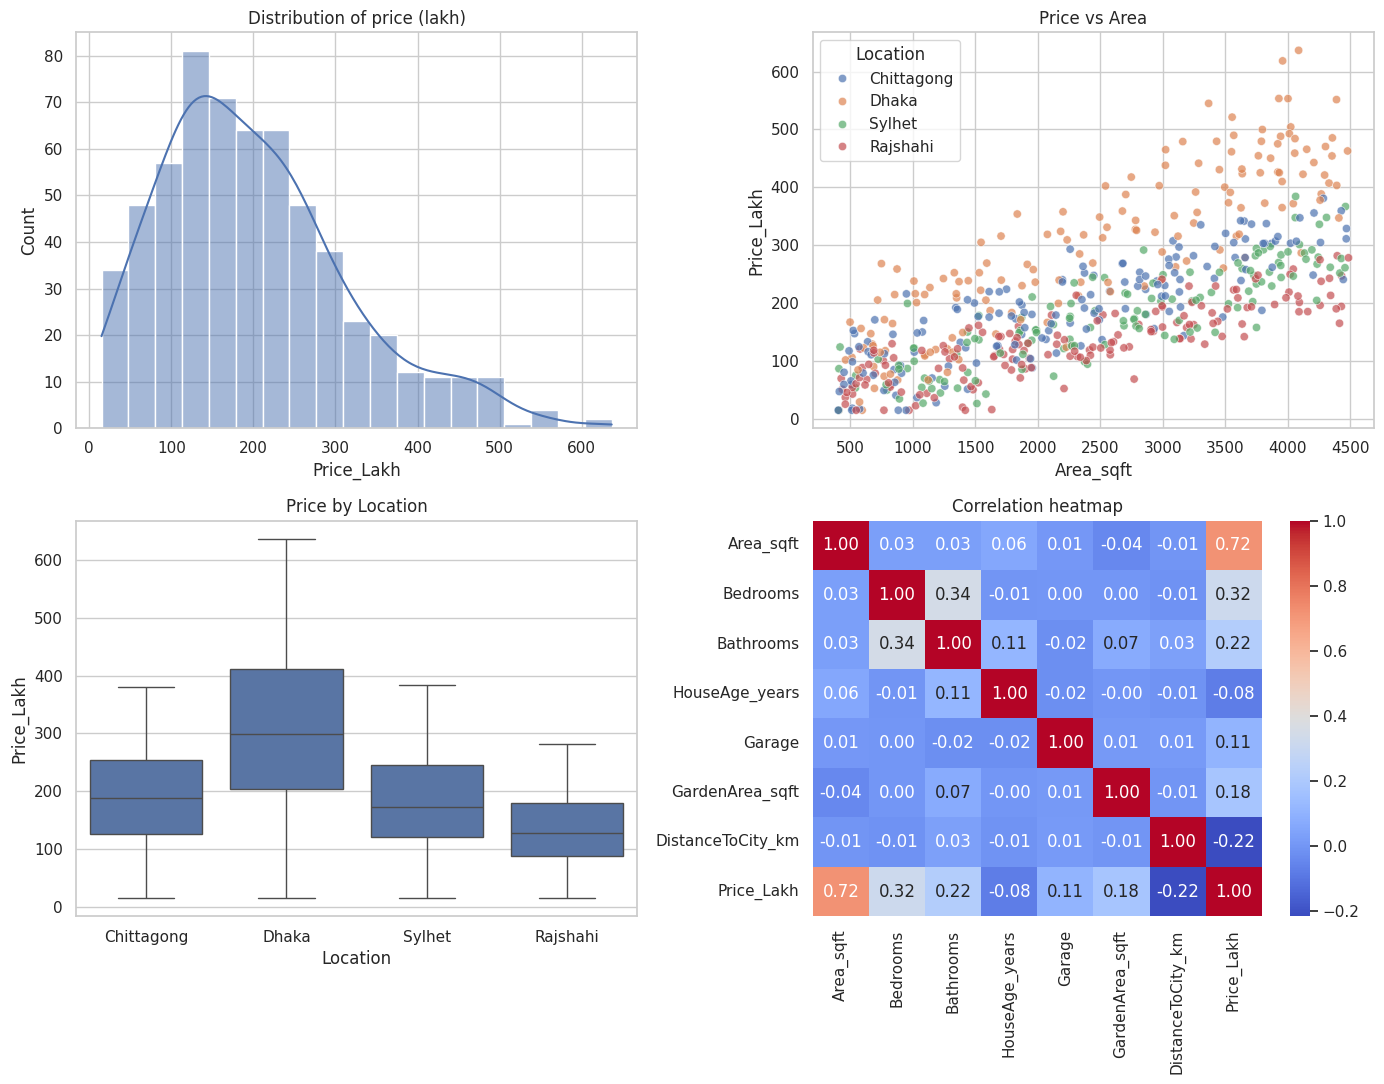

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

sns.histplot(df["Price_Lakh"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of price (lakh)")

sns.scatterplot(data=df, x="Area_sqft", y="Price_Lakh", hue="Location", alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title("Price vs Area")

sns.boxplot(data=df, x="Location", y="Price_Lakh", ax=axes[1, 0])
axes[1, 0].set_title("Price by Location")

num = df.drop(columns=["HouseID"]).select_dtypes("number")
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation heatmap")

plt.tight_layout()
plt.show()

## 4. Train / test split & preparation

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Fill values learned from TRAINING data only
garden_median = train_df["GardenArea_sqft"].median()
dist_median_by_loc = train_df.groupby("Location")["DistanceToCity_km"].median()
dist_median_all = train_df["DistanceToCity_km"].median()
locations = sorted(train_df["Location"].unique())
print("Locations:", locations, "| reference (dropped) city:", locations[0])

def prepare(data):
    X = data.drop(columns=["HouseID", "Price_Lakh"], errors="ignore").copy()
    X["Garden_missing"] = X["GardenArea_sqft"].isna().astype(int)
    X["GardenArea_sqft"] = X["GardenArea_sqft"].fillna(garden_median)
    X["DistanceToCity_km"] = (X["DistanceToCity_km"]
                              .fillna(X["Location"].map(dist_median_by_loc))
                              .fillna(dist_median_all))
    X["Location"] = pd.Categorical(X["Location"], categories=locations)
    X = pd.get_dummies(X, columns=["Location"], drop_first=True, dtype=int)
    return X

X_train, y_train = prepare(train_df), train_df["Price_Lakh"]
X_test,  y_test  = prepare(test_df)[X_train.columns], test_df["Price_Lakh"]
print("Train:", X_train.shape, " Test:", X_test.shape)
X_train.head()

Locations: ['Chittagong', 'Dhaka', 'Rajshahi', 'Sylhet'] | reference (dropped) city: Chittagong
Train: (480, 11)  Test: (120, 11)


,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Garden_missing,Location_Dhaka,Location_Rajshahi,Location_Sylhet
145,1850,5,2,35,1,0.00,9.70,0,0,0,1
9,3456,2,3,24,0,0.00,22.30,0,1,0,0
375,1610,7,5,6,1,0.00,15.30,0,0,0,0
523,3050,6,5,13,0,413.50,20.10,1,0,0,0
188,3439,2,1,40,1,"1,670.00",17.50,0,0,1,0


## 5. Baseline model – Area_sqft only

In [ ]:
def evaluate(name, y_true, y_pred):
    return {"Model": name,
            "R²": r2_score(y_true, y_pred),
            "MAE (lakh)": mean_absolute_error(y_true, y_pred),
            "RMSE (lakh)": np.sqrt(mean_squared_error(y_true, y_pred))}

base = LinearRegression().fit(X_train[["Area_sqft"]], y_train)
pred_base = base.predict(X_test[["Area_sqft"]])
print(f"Baseline: Price = {base.intercept_:.2f} + {base.coef_[0]:.4f} × Area_sqft")
evaluate("Baseline (Area only)", y_test, pred_base)

Baseline: Price = 30.78 + 0.0700 × Area_sqft


{'Model': 'Baseline (Area only)',
 'R²': 0.425772168094378,
 'MAE (lakh)': 68.82855527657006,
 'RMSE (lakh)': np.float64(89.16558272898737)}

## 6. Improved model – multiple regression (all useful features)

In [ ]:
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

results = pd.DataFrame([
    evaluate("Baseline (Area only)", y_test, pred_base),
    evaluate("Multiple regression", y_test, pred),
])
results

,Model,R²,MAE (lakh),RMSE (lakh)
0,Baseline (Area only),0.43,68.83,89.17
1,Multiple regression,0.93,24.32,31.73


## 7. Evaluation on the test set

In [ ]:
r = results.set_index("Model")
for m in r.index:
    print(f"{m}: R² = {r.loc[m,'R²']:.3f} → explains {r.loc[m,'R²']*100:.0f}% of price variation; "
          f"predictions are typically off by about ±{r.loc[m,'RMSE (lakh)']:.1f} lakh "
          f"(average absolute error {r.loc[m,'MAE (lakh)']:.1f} lakh).")

Baseline (Area only): R² = 0.426 → explains 43% of price variation; predictions are typically off by about ±89.2 lakh (average absolute error 68.8 lakh).
Multiple regression: R² = 0.927 → explains 93% of price variation; predictions are typically off by about ±31.7 lakh (average absolute error 24.3 lakh).


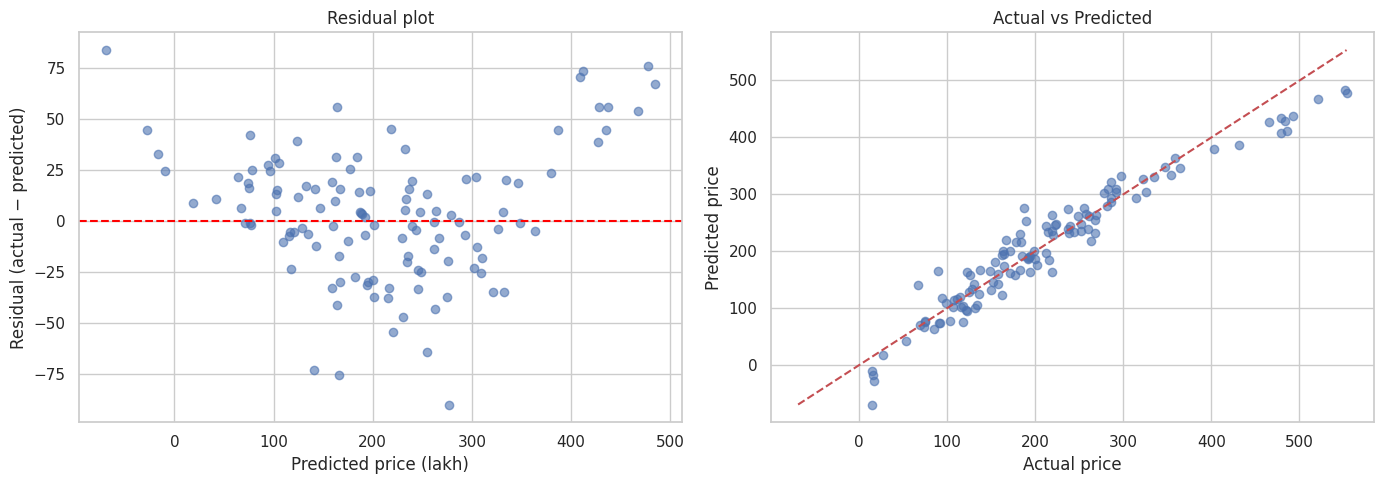

,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Price_Lakh,Predicted,Error
199,3200,Dhaka,1618,5,4,29,0,"1,750.80",NaN,187.00,276.86,-89.86
537,3538,Rajshahi,546,2,3,40,0,0.00,25.50,15.00,-68.72,83.72
434,3435,Dhaka,3928,6,2,2,0,"1,373.60",3.90,553.40,477.39,76.01
63,3064,Dhaka,686,5,1,34,0,0.00,2.10,90.40,166.03,-75.63
589,3590,Dhaka,4356,2,2,12,1,825.40,15.70,485.40,411.70,73.70


In [ ]:
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(pred, resid, alpha=0.6)
ax[0].axhline(0, color="red", ls="--")
ax[0].set(xlabel="Predicted price (lakh)", ylabel="Residual (actual − predicted)", title="Residual plot")

ax[1].scatter(y_test, pred, alpha=0.6)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax[1].plot(lims, lims, "r--")
ax[1].set(xlabel="Actual price", ylabel="Predicted price", title="Actual vs Predicted")
plt.tight_layout(); plt.show()

# Houses the model gets most wrong
worst = test_df.assign(Predicted=pred, Error=resid)
worst.loc[resid.abs().sort_values(ascending=False).index].head(5)

## 8. Coefficients – business interpretation

In [ ]:
coef = pd.DataFrame({"Feature": X_train.columns, "Coefficient (lakh per unit)": model.coef_})
# Standardised effect = coefficient × std of feature → lets us compare features fairly
coef["Effect of +1 std (lakh)"] = coef["Coefficient (lakh per unit)"] * X_train.std().values
coef = coef.sort_values("Effect of +1 std (lakh)", key=abs, ascending=False)
print("Intercept:", round(model.intercept_, 2))
coef

Intercept: -7.17


,Feature,Coefficient (lakh per unit),Effect of +1 std (lakh)
0,Area_sqft,0.07,81.49
8,Location_Dhaka,93.03,40.66
1,Bedrooms,13.95,27.20
6,DistanceToCity_km,-2.30,-22.74
9,Location_Rajshahi,-46.69,-20.72
5,GardenArea_sqft,0.03,17.36
3,HouseAge_years,-1.16,-13.98
2,Bathrooms,8.58,11.78
4,Garage,15.13,7.56
10,Location_Sylhet,-15.94,-6.57


In [ ]:
c = dict(zip(X_train.columns, model.coef_))
print(f"• Every extra 100 sqft adds about {c['Area_sqft']*100:.2f} lakh, other things equal.")
print(f"• Each extra year of age changes price by about {c['HouseAge_years']:.2f} lakh.")
print(f"• Each extra km from the city changes price by about {c['DistanceToCity_km']:.2f} lakh.")
for col in [k for k in c if k.startswith("Location_")]:
    print(f"• A house in {col.replace('Location_','')} costs about {c[col]:.2f} lakh "
          f"more/less than an identical house in {locations[0]}.")

• Every extra 100 sqft adds about 6.73 lakh, other things equal.
• Each extra year of age changes price by about -1.16 lakh.
• Each extra km from the city changes price by about -2.30 lakh.
• A house in Dhaka costs about 93.03 lakh more/less than an identical house in Chittagong.
• A house in Rajshahi costs about -46.69 lakh more/less than an identical house in Chittagong.
• A house in Sylhet costs about -15.94 lakh more/less than an identical house in Chittagong.


*Note: the raw coefficient depends on units (1 sqft vs 1 bedroom), so the biggest raw number is not automatically the most important feature — compare the standardised column. Bedrooms may even get a negative sign because it is correlated with Area (multicollinearity): at the same area, more bedrooms means smaller rooms.*

## 9. Predict 3 example houses

In [ ]:
examples = pd.DataFrame([
    {"Location": locations[0],  "Area_sqft": 1200, "Bedrooms": 3, "Bathrooms": 2, "HouseAge_years": 5,
     "Garage": 1, "GardenArea_sqft": 0,   "DistanceToCity_km": 4},
    {"Location": locations[1],  "Area_sqft": 1800, "Bedrooms": 4, "Bathrooms": 3, "HouseAge_years": 12,
     "Garage": 1, "GardenArea_sqft": 300, "DistanceToCity_km": 10},
    {"Location": locations[-1], "Area_sqft": 900,  "Bedrooms": 2, "Bathrooms": 1, "HouseAge_years": 20,
     "Garage": 0, "GardenArea_sqft": 0,   "DistanceToCity_km": 15},
])
examples["Predicted_Price_Lakh"] = model.predict(prepare(examples)[X_train.columns]).round(1)
examples

,Location,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Predicted_Price_Lakh
0,Chittagong,1200,3,2,5,1,0,4,132.70
1,Dhaka,1800,4,3,12,1,300,10,274.90
2,Sylhet,900,2,1,20,0,0,15,16.10


##Stretch 1 – Decision Tree vs Linear Regression

In [ ]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
results = pd.concat([results, pd.DataFrame([evaluate("Decision Tree (depth 5)", y_test, tree.predict(X_test))])],
                    ignore_index=True)
results

,Model,R²,MAE (lakh),RMSE (lakh)
0,Baseline (Area only),0.43,68.83,89.17
1,Multiple regression,0.93,24.32,31.73
2,Decision Tree (depth 5),0.76,45.39,57.50


##Stretch 2 – Price calculator (change the values on the right, then run)

In [ ]:
#@title 🏠 Price calculator
Location = "Dhaka" #@param ["Dhaka", "Chattogram", "Sylhet", "Rajshahi"] {allow-input: true}
Area_sqft = 1200 #@param {type:"number"}
Bedrooms = 3 #@param {type:"integer"}
Bathrooms = 2 #@param {type:"integer"}
HouseAge_years = 5 #@param {type:"number"}
Garage = 1 #@param {type:"integer"}
GardenArea_sqft = 0 #@param {type:"number"}
DistanceToCity_km = 5 #@param {type:"number"}

if Location not in locations:
    print(f"'{Location}' not found in data. Use one of: {locations}")
else:
    house = pd.DataFrame([dict(Location=Location, Area_sqft=Area_sqft, Bedrooms=Bedrooms,
                               Bathrooms=Bathrooms, HouseAge_years=HouseAge_years, Garage=Garage,
                               GardenArea_sqft=GardenArea_sqft, DistanceToCity_km=DistanceToCity_km)])
    p = model.predict(prepare(house)[X_train.columns])[0]
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"Estimated asking price: {p:.1f} lakh  (typical error ±{rmse:.1f} lakh)")

Estimated asking price: 223.5 lakh  (typical error ±31.7 lakh)
